# Stage 1 — Exploring PJTL operating tables before modeling

**Audience:** Analysts and engineers who want to see what is in the project data and how the readiness label is defined.

**By the end of this notebook you will have:** inspected each delivered CSV, understood class balance for `label_ready`, explored correlations among the nine launch metrics, and produced `stage1_model_frame.csv` for Stage 2.

**Where the numbers come from:** Team workbooks live in **`inputs/`** (repo root). The **table build step** writes CSVs to **`intermediates/phase1/`**; `python code/inference_engine/scripts/sync_inputs_from_phase1.py` copies a flat snapshot to **`intermediates/inference_inputs/`** (same as `code/inference_engine/inputs` via symlink). This notebook reads that snapshot.

## What `label_ready` means here
- **`label_ready = 1`:** All nine numeric inputs satisfy the same pass/fail rules as the nine launch-readiness gates (each column is treated like the corresponding gate metric).
- **`label_ready = 0`:** At least one gate would fail.
- The live API also applies a readiness classifier on **how many** gates pass. The **binary training label** is the strict “all nine pass” slice so XGBoost learns the gate boundaries in feature space.

## Research questions
1. What does each PJTL-provided table contain (shape, quality, drift risk) before any modeling?
2. How complete and balanced is the readiness training frame?
3. Which feature pairs move together (redundancy) vs act as independent levers?
4. Where do alternate formula branches show up when we reconstruct week-level KPIs from raw bases?
5. What row-level **analysis-only** composites help stress-test narratives without changing the backend feature contract?


## What files came from the PJTL / RYW side?

**Operating data tables** built from the workbooks live under **`intermediates/phase1/`**. The inference engine **does not pull data from the web**. It loads **copies** from **`intermediates/inference_inputs/`**. The index file `MANIFEST.json` there lists each file name, row count, and path back to `intermediates/phase1/`.

**Treat every column as “given by the project” unless you have a separate field dictionary note.** Stage 1’s job is to **question** those inputs (missing values, impossible ranges, duplicates) — not to assume they are perfect.

Common tables in `inputs/` include:
- `contract_volume_base.csv`, `driver_active_time_base.csv`, `field_dictionary.csv`, `join_key_inventory.csv`, `minimum_viable_subset.csv`, `missingness_audit.csv`, `mode_breakdown_base.csv`, `mode_summary_base.csv`, `payer_summary_base.csv`, `prospective_intake_base.csv`, `quarantine_list.csv`, **`readiness_training_base.csv`** (the nine gate-style metrics + `label_ready`), `securecare_profit_base.csv`, `sheet_lineage_map.csv`, `unit_dictionary.csv`, `vehicle_day_base.csv`, `weekly_margin_base.csv`.

Gate definitions and thresholds are versioned in `code/config/pjtl_kpis_and_formulas.json` (same file the backend uses).


In [1]:
from __future__ import annotations
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="talk")

HERE = Path.cwd().resolve()
def _repo_root(here: Path) -> Path:
    for p in [here, *here.parents]:
        if (p / "code" / "config" / "pjtl_kpis_and_formulas.json").is_file():
            return p
    raise RuntimeError("Cannot find repo root (missing code/config/pjtl_kpis_and_formulas.json)")

REPO_ROOT = _repo_root(HERE)
ENGINE = REPO_ROOT / "code" / "inference_engine"
CODE_ROOT = REPO_ROOT / "code"
INPUTS = REPO_ROOT / "code" / "intermediates" / "inference_inputs"
RESULTS = REPO_ROOT / "code" / "outputs" / "reports" / "stage1"
PLOTS = REPO_ROOT / "code" / "outputs" / "plots" / "stage1"
RESULTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
KPI_DOC = CODE_ROOT / "config" / "pjtl_kpis_and_formulas.json"

with KPI_DOC.open(encoding="utf-8") as fh:
    _kpi_cfg = json.load(fh)
BACKEND_FEATURES = [m["key"] for m in _kpi_cfg["readiness_metrics"]]

manifest = json.loads((INPUTS / "MANIFEST.json").read_text(encoding="utf-8"))
prov_rows = []
for f in manifest.get("files", []):
    prov_rows.append({
        "filename": f.get("filename"),
        "rows": f.get("rows"),
        "source_relative": f.get("source_relative", ""),
    })
prov_df = pd.DataFrame(prov_rows).dropna(subset=["filename"])
prov_df.to_csv(RESULTS / "provenance_table.csv", index=False)
display(Markdown("### Tables loaded for this analysis"))
display(prov_df[["filename", "rows", "source_relative"]])


### Tables loaded for this analysis

,filename,rows,source_relative
0,contract_volume_base.csv,8087,code/intermediates/phase1/contract_volume_base...
1,driver_active_time_base.csv,773,code/intermediates/phase1/driver_active_time_b...
2,field_dictionary.csv,274,code/intermediates/phase1/field_dictionary.csv
3,join_key_inventory.csv,7,code/intermediates/phase1/join_key_inventory.csv
4,minimum_viable_subset.csv,8,code/intermediates/phase1/minimum_viable_subse...
5,missingness_audit.csv,274,code/intermediates/phase1/missingness_audit.csv
6,mode_breakdown_base.csv,17927,code/intermediates/phase1/mode_breakdown_base.csv
7,mode_summary_base.csv,215,code/intermediates/phase1/mode_summary_base.csv
8,payer_summary_base.csv,1499,code/intermediates/phase1/payer_summary_base.csv
9,prospective_intake_base.csv,8,code/intermediates/phase1/prospective_intake_b...


### Nine launch-readiness KPIs (shared config)

Rules below match the backend viability checks. Full detail: `code/config/pjtl_kpis_and_formulas.json`.


In [2]:
_rule_txt = {"gte": "value ≥ threshold", "lte": "value ≤ threshold", "lt": "value < threshold (strict)"}
kpi_rows = []
for m in _kpi_cfg["readiness_metrics"]:
    kpi_rows.append({
        "#": m["metric_number"],
        "KPI": m["display_name"],
        "Target": m["target_phrase"],
        "Pass rule": _rule_txt.get(m["pass_rule"], m["pass_rule"]),
        "Column": m["key"],
    })
display(pd.DataFrame(kpi_rows))


,#,KPI,Target,Pass rule,Column
0,1,Vehicle utilization,at least 95%,value ≥ threshold,vehicle_utilization
1,2,Billed utilization,at least 105%,value ≥ threshold,billed_utilization
2,3,Total volume pool,at least 120%,value ≥ threshold,total_volume_pool
3,4,Revenue per Kent-Leg,at least $70 per Kent-Leg,value ≥ threshold,revenue_per_kent_leg
4,5,High-acuity trip mix (SA/SC),at least 5%,value ≥ threshold,high_acuity_share
5,6,Non-billable no-show rate,strictly below 10%,value < threshold (strict),non_billable_noshow
6,7,Road hours per vehicle per day,at least 9 hours,value ≥ threshold,road_hours_per_vehicle
7,8,Contract concentration,no single contract above 20% of volume or revenue,value ≤ threshold,contract_concentration
8,9,Cost per road hour,at most $50 per road hour,value ≤ threshold,cost_per_road_hour


### Raw workbooks on disk

The next cell checks that the Excel sources listed in `MANIFEST.upstream.json` still exist under the repo (after you run the sync script). Set `STRICT_PROVENANCE=1` to **stop** the notebook if anything is missing.


In [3]:
# Optional: expected .xlsx paths from last sync
import os
from pathlib import Path
from IPython.display import display, Markdown

REPO_ROOT = ENGINE.parents[1]
UPSTREAM_PATH = INPUTS / "MANIFEST.upstream.json"
strict = os.environ.get("STRICT_PROVENANCE", "").strip() == "1"

if not UPSTREAM_PATH.is_file():
    msg = (
        f"Missing `{UPSTREAM_PATH.name}`. From repo root run:\n\n"
        "`python code/scripts/build_phase1_canonical_base.py`\n\n"
        "`python code/scripts/build_readiness_training_base.py`\n\n"
        "`python code/inference_engine/scripts/sync_inputs_from_phase1.py`\n"
    )
    if strict:
        raise FileNotFoundError(msg)
    display(Markdown(f"**Warning:** {msg}"))
else:
    up = json.loads(UPSTREAM_PATH.read_text(encoding="utf-8"))
    rows = []
    missing = []
    for w in up.get("workbooks", []):
        rel = w.get("repo_relative_path", "")
        p = REPO_ROOT / rel
        ok = p.is_file()
        rows.append({"repo_path": rel, "present": ok})
        if not ok:
            missing.append(rel)
    display(Markdown("### Upstream workbook files"))
    display(pd.DataFrame(rows))
    if missing and strict:
        raise FileNotFoundError("Missing workbooks: " + ", ".join(missing))
    if missing:
        display(Markdown("**Note:** Some paths are missing; refresh raw files or re-run the table build + sync if needed."))


### Upstream workbook files

,repo_path,present
0,code/inputs/Q1 Daily Metrics 2026.xlsx,True
1,code/inputs/RideYourWay_Prospective_Market_Int...,True
2,code/inputs/RideYourWay_Prospective_Market_Int...,True


### Formula and gate authority

Numeric gate thresholds, pass rules (`≥`, `≤`, strict `<`), Kent-Leg constants, and short business meanings live in **`code/config/pjtl_kpis_and_formulas.json`** (`schema_version` field). Shared feature helpers: `code/inference_engine/src/features.py`.


In [4]:

# Load every manifest-listed CSV we ship under inputs/
import os
tables = {}
for f in manifest.get("files", []):
    fn = f.get("filename")
    if not fn.endswith(".csv"):
        continue
    p = INPUTS / fn
    if p.exists():
        tables[fn.replace(".csv","")] = pd.read_csv(p)
inv = pd.DataFrame([{"table": k, "rows": len(v), "cols": len(v.columns)} for k,v in tables.items()])
inv.to_csv(RESULTS / "table_inventory.csv", index=False)
display(inv)


,table,rows,cols
0,contract_volume_base,8087,20
1,driver_active_time_base,773,8
2,field_dictionary,274,11
3,join_key_inventory,7,6
4,minimum_viable_subset,8,3
5,missingness_audit,274,7
6,mode_breakdown_base,17927,21
7,mode_summary_base,215,11
8,payer_summary_base,1499,11
9,prospective_intake_base,8,68


#### Observation → Inference → Decision relevance
**Sanity pass** catches wrong dtypes, accidental constants, and join-key collisions before trusting any plot.


In [5]:

# Per-table trivial EDA: head/tail, dtypes, memory, constants
lines = []
for name, df in sorted(tables.items()):
    h = df.head(3).to_string()
    t = df.tail(3).to_string()
    lines.append(f"=== {name} ===\nHEAD\n{h}\nTAIL\n{t}\n")
    dty = pd.DataFrame({"column": df.columns, "dtype": [str(df[c].dtype) for c in df.columns]})
    dty.to_csv(RESULTS / f"dtypes_{name}.csv", index=False)
    const = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    if const:
        pd.DataFrame({"constant_columns": const}).to_csv(RESULTS / f"constant_columns_{name}.csv", index=False)
    dup_n = int(df.duplicated().sum())
    pd.DataFrame([{"table": name, "duplicate_rows": dup_n, "memory_mb": df.memory_usage(deep=True).sum()/1024**2}]).to_csv(
        RESULTS / f"dup_memory_{name}.csv", index=False
    )
(RESULTS / "head_tail_log.txt").write_text("\n".join(lines), encoding="utf-8")
display(Markdown("Wrote per-table dtypes, constants, duplicate/memory summaries under `results/stage1/`."))


Wrote per-table dtypes, constants, duplicate/memory summaries under `results/stage1/`.

In [6]:

# Numeric describe + quantiles (per table)
parts = []
for name, df in sorted(tables.items()):
    num = df.select_dtypes(include=[np.number])
    if num.shape[1] == 0:
        continue
    desc = num.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T
    desc.insert(0, "table", name)
    parts.append(desc.reset_index().rename(columns={"index":"column"}))
if parts:
    all_desc = pd.concat(parts, ignore_index=True)
    all_desc.to_csv(RESULTS / "describe_numeric.csv", index=False)
    display(all_desc.head(20))


,column,table,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,order_mileage,contract_volume_base,8087.0,15.332745,19.892623,0.100000,0.540000,1.020000,4.380000,8.000000,16.000000,60.000000,90.770200,254.370000
1,order_price,contract_volume_base,8087.0,53.617079,87.046592,0.000000,0.000000,0.000000,0.000000,46.000000,71.275000,152.584000,468.260000,1545.720000
2,date_of_service,contract_volume_base,8087.0,46037.510078,9.762838,46020.000000,46020.000000,46021.000000,46029.000000,46037.000000,46045.000000,46051.000000,46052.000000,46053.000000
3,pick_up_time,contract_volume_base,8087.0,46038.003617,9.765355,46020.215278,46020.433129,46021.500000,46029.603819,46037.604167,46045.647569,46051.666667,46052.639861,46053.690972
4,offset,contract_volume_base,8087.0,7.332745,19.892623,-7.900000,-7.460000,-6.980000,-3.620000,0.000000,8.000000,52.000000,82.770200,246.370000
5,over_under,contract_volume_base,8087.0,0.349178,0.947268,-0.376190,-0.355238,-0.332381,-0.172381,0.000000,0.380952,2.476190,3.941438,11.731905
6,mileage_kent_legs,contract_volume_base,8087.0,1.186421,0.623260,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.476190,3.941438,11.731905
7,kent_legs,contract_volume_base,8087.0,1.337899,0.912910,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.476190,4.941438,12.731905
8,date,driver_active_time_base,773.0,46036.564036,9.720983,46020.000000,46020.000000,46021.000000,46029.000000,46036.000000,46044.000000,46051.000000,46052.000000,46053.000000
9,road_time,driver_active_time_base,773.0,8.678862,2.790666,0.000000,0.000000,4.340833,7.848333,8.418611,9.712222,12.949611,18.203578,19.695556


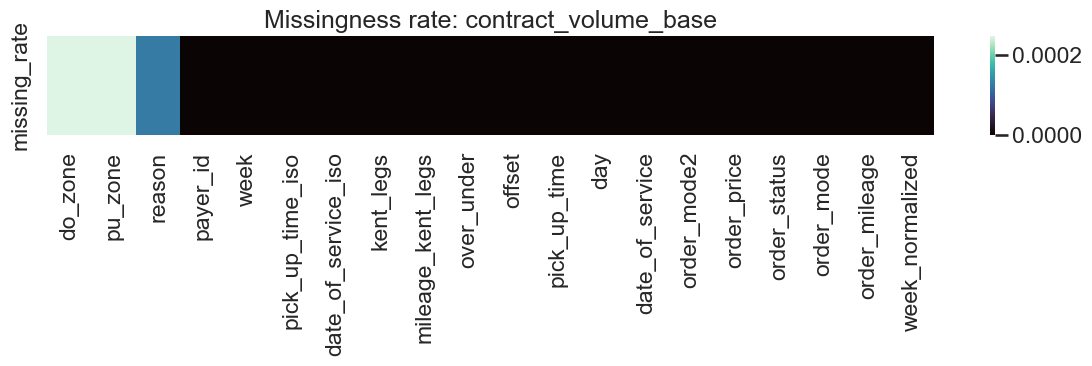

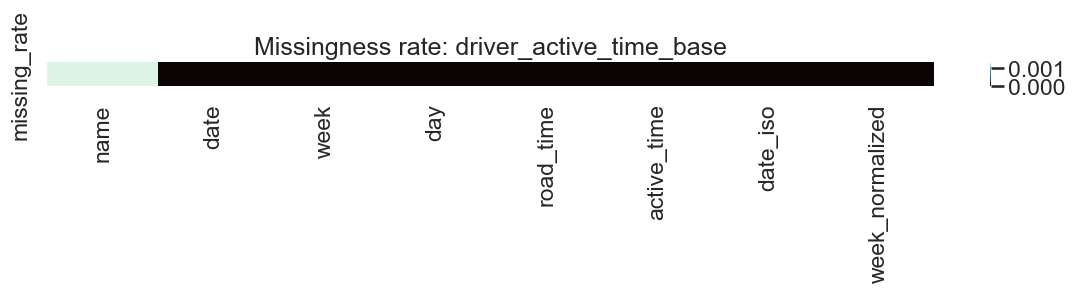

/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_94809/4070390181.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


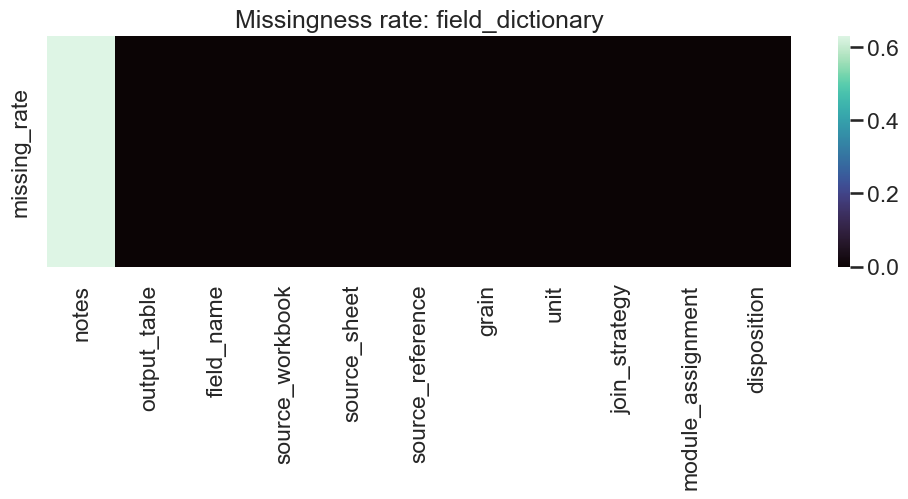

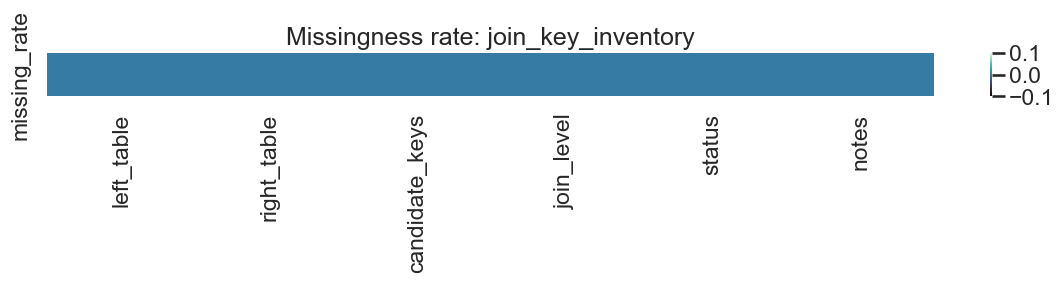

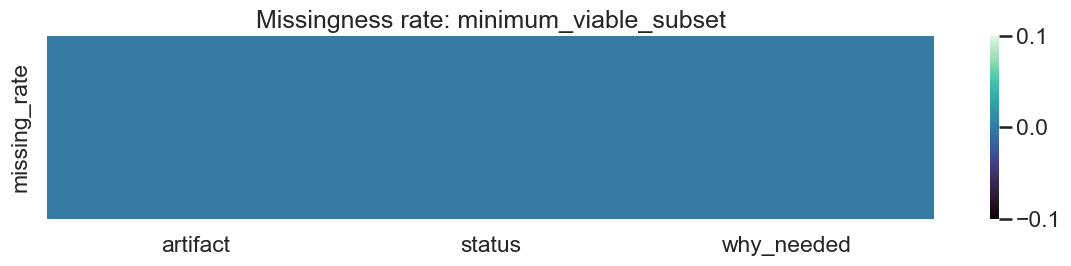

/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_94809/4070390181.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


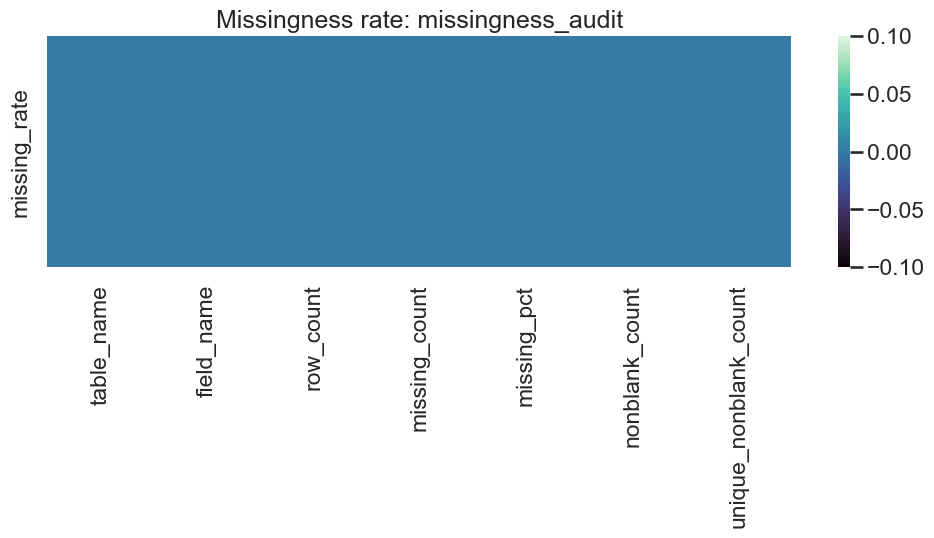

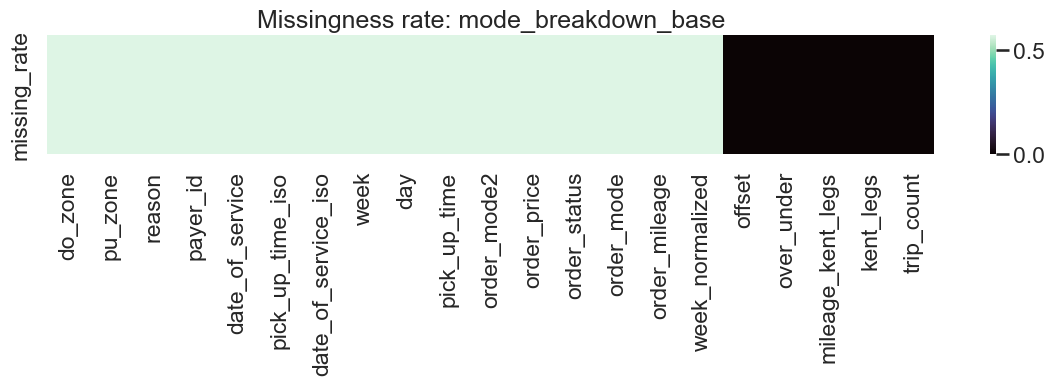

/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_94809/4070390181.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


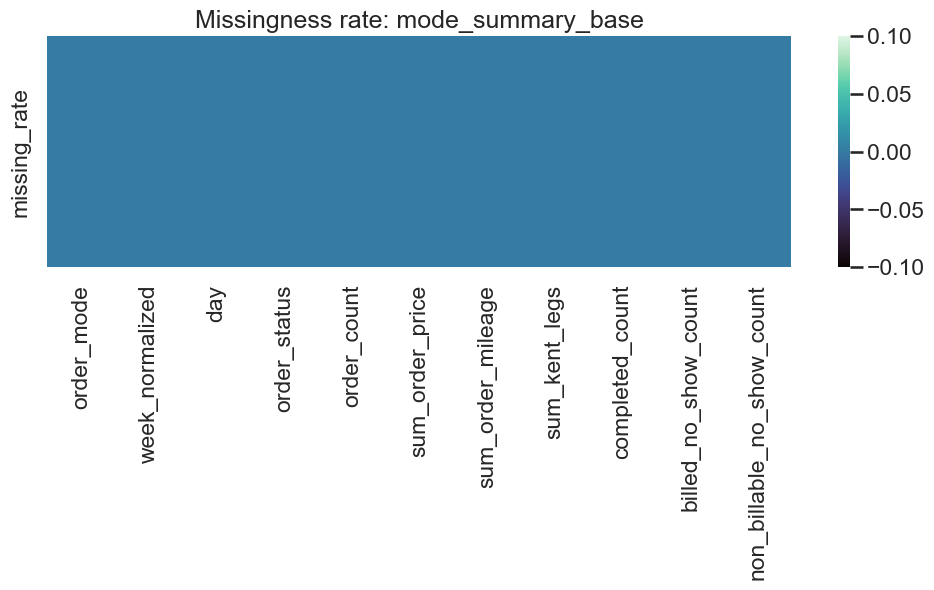

/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_94809/4070390181.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


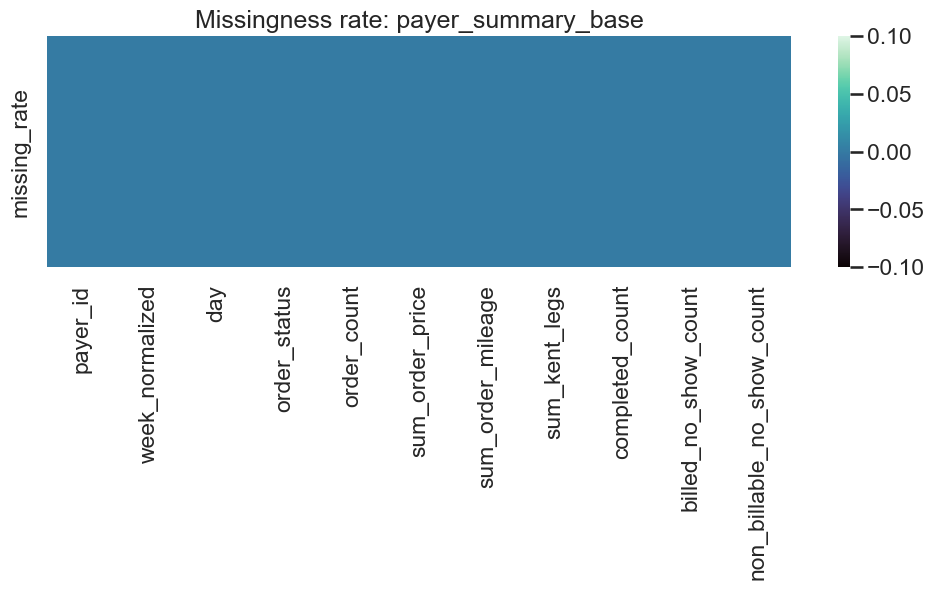

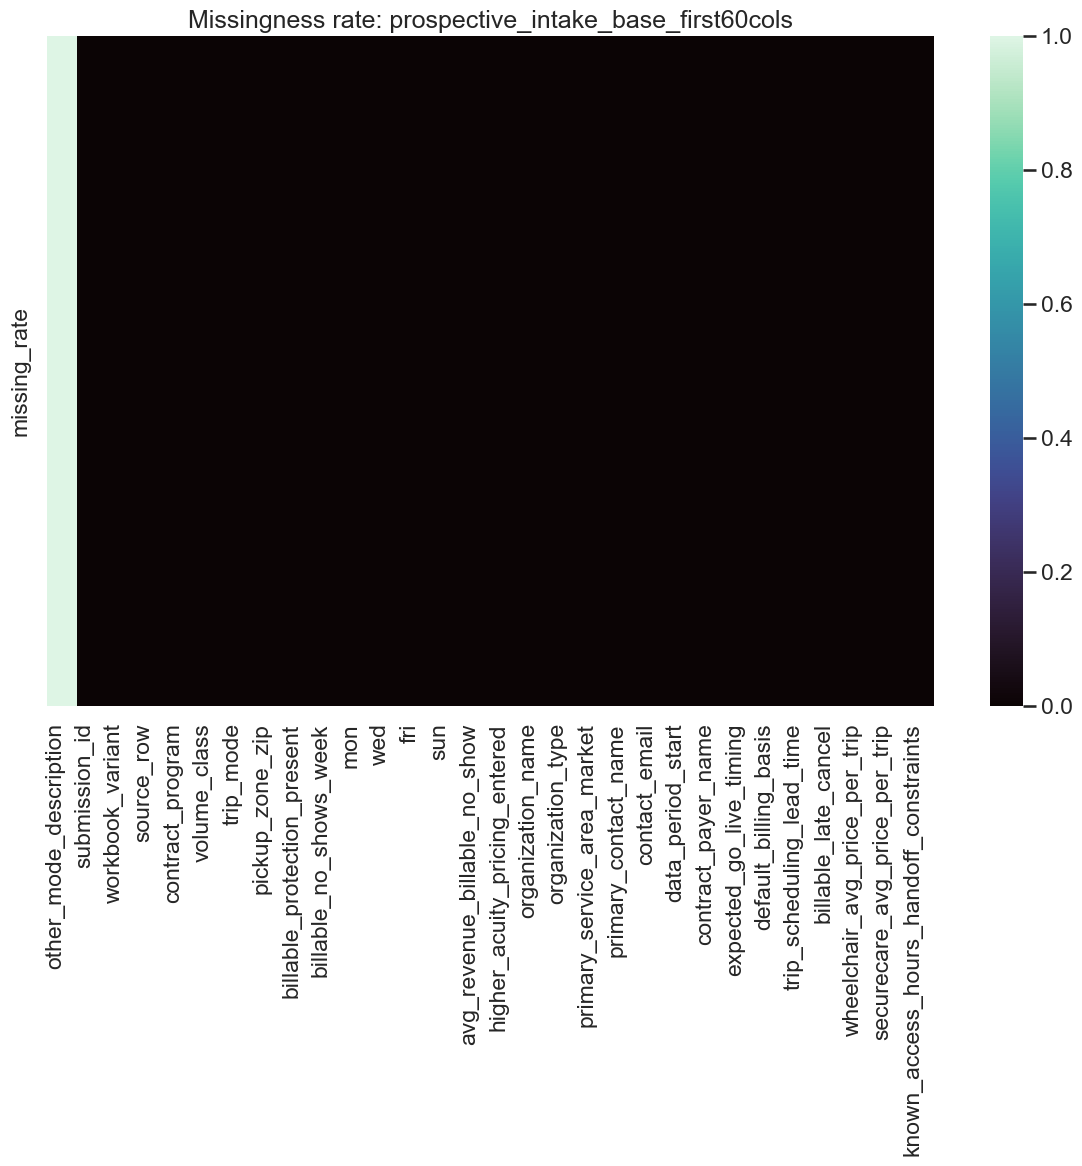

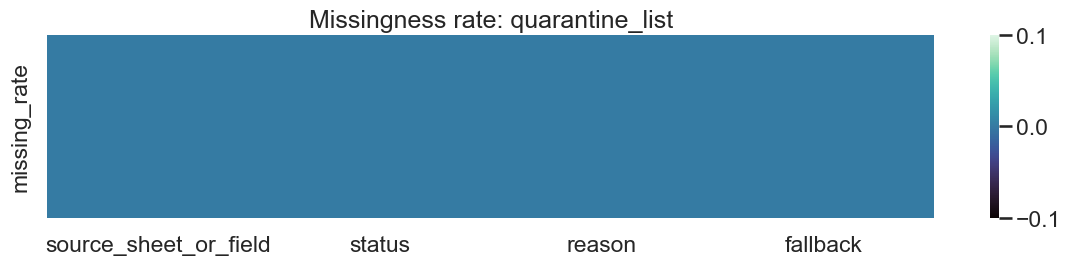

/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_94809/4070390181.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


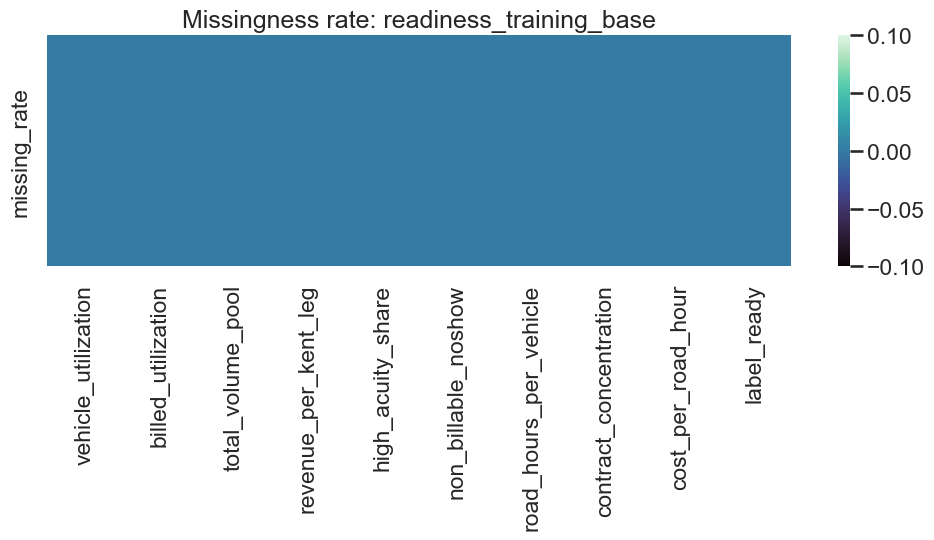

/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_94809/4070390181.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


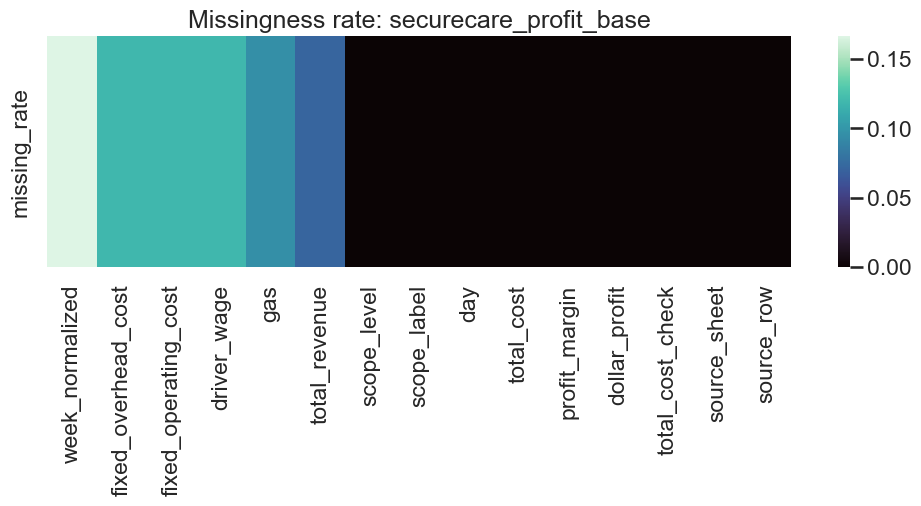

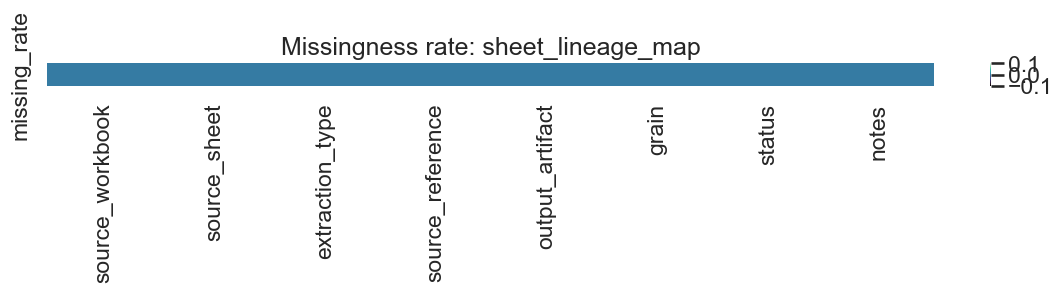

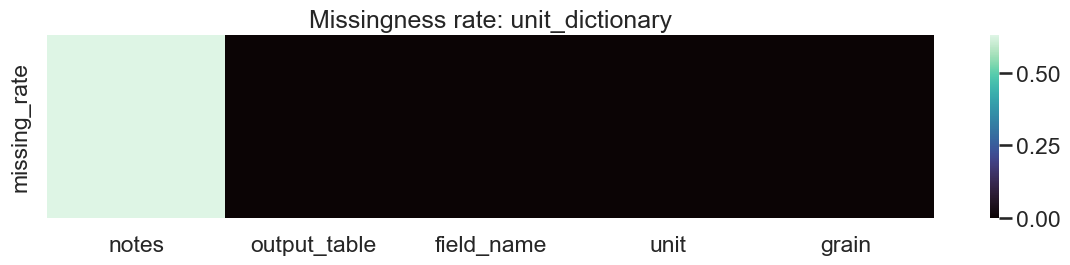

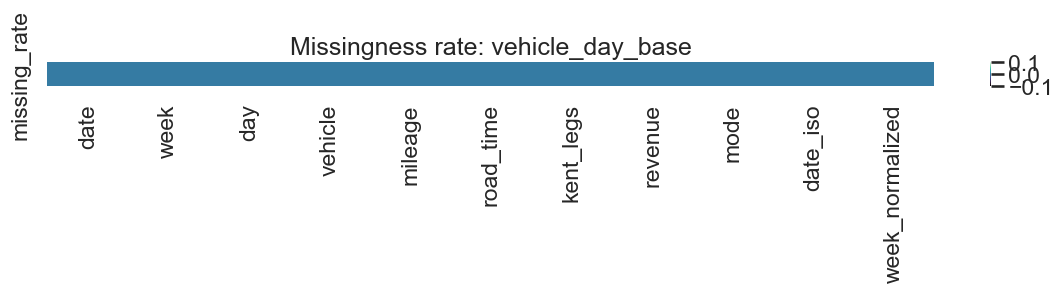

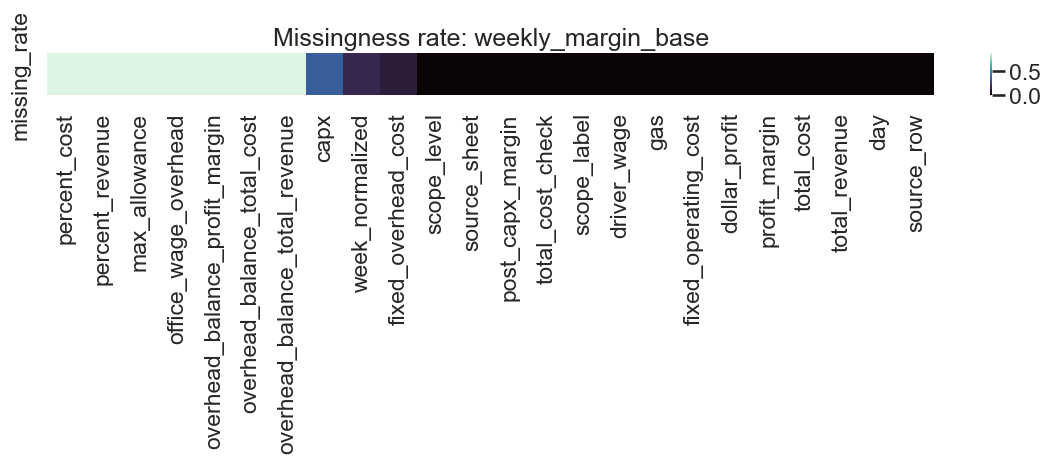

In [7]:

# Missingness heatmaps (truncate wide tables for readability)
for name, df in sorted(tables.items()):
    if df.shape[1] > 60:
        sub = df.iloc[:, :60]
        tag = f"{name}_first60cols"
    else:
        sub = df
        tag = name
    miss = sub.isna().mean().sort_values(ascending=False)
    miss.to_csv(RESULTS / f"missingness_rate_{tag}.csv")
    if miss.shape[0] >= 2:
        plt.figure(figsize=(12, max(3, miss.shape[0]*0.2)))
        sns.heatmap(miss.to_frame("missing_rate").T, cmap="mako", cbar=True)
        plt.title(f"Missingness rate: {tag}")
        plt.tight_layout()
        plt.savefig(PLOTS / f"missingness_{tag}.png", dpi=120)
        plt.show()


### Readiness training frame (backend contract features)
This is the only row-level set guaranteed to align with production inference features.

**`label_ready` recap:** `1` means all nine numeric columns pass the same gate rules as in `code/config/pjtl_kpis_and_formulas.json`; `0` means at least one fails. The plots below show class counts on the full training extract (including rows with missing features that Stage 1 will drop before modeling).


,vehicle_utilization,billed_utilization,total_volume_pool,revenue_per_kent_leg,high_acuity_share,non_billable_noshow,road_hours_per_vehicle,contract_concentration,cost_per_road_hour,label_ready
0,1.204750,1.255250,1.256509,97.850000,0.200250,0.049500,12.545000,0.124000,38.750000,1
1,1.303194,1.350795,1.395783,91.647750,0.085925,0.023881,11.119528,0.097915,31.850878,1
2,0.551298,1.421853,1.163103,39.159138,0.017746,0.213132,11.913132,0.304582,81.443718,0
3,1.204750,1.255250,1.606000,97.850000,0.200250,0.049500,12.545000,0.204285,38.750000,0
4,1.393167,1.316086,1.748172,84.482451,0.175572,0.036645,12.650102,0.119334,35.191764,1


,vehicle_utilization,billed_utilization,total_volume_pool,revenue_per_kent_leg,high_acuity_share,non_billable_noshow,road_hours_per_vehicle,contract_concentration,cost_per_road_hour,label_ready
3995,1.204750,1.255250,1.606000,69.300000,0.200250,0.049500,12.545000,0.124000,38.750000,0
3996,0.901872,0.587724,1.467222,113.886140,0.020486,0.251250,6.799356,0.195976,31.113687,0
3997,1.204750,1.255250,1.606000,97.850000,0.200250,0.049500,12.545000,0.193096,38.750000,1
3998,1.377074,1.363134,1.885792,111.803782,0.260972,0.001013,13.382716,0.068072,29.290677,1
3999,0.995683,1.255250,1.606000,97.850000,0.200250,0.049500,12.545000,0.124000,38.750000,1


,label,count,rate
0,1,2027,0.50675
1,0,1973,0.49325


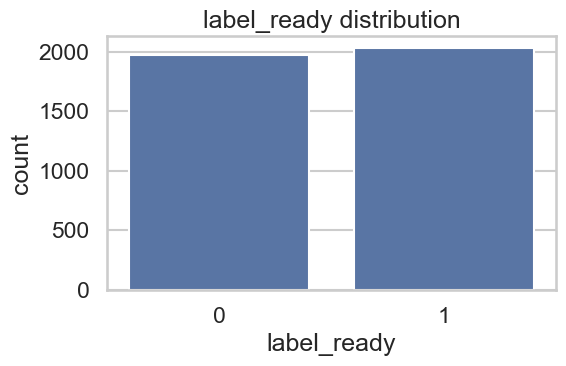

In [8]:

rt = tables.get("readiness_training_base")
if rt is None:
    raise RuntimeError("readiness_training table missing")
train = rt.copy()
for c in BACKEND_FEATURES + ["label_ready"]:
    train[c] = pd.to_numeric(train[c], errors="coerce")

miss_rt = train.isna().mean().rename("missing_rate").reset_index().rename(columns={"index":"feature"})
miss_rt.to_csv(RESULTS / "missingness_readiness_training.csv", index=False)

bal = train["label_ready"].value_counts(dropna=False).rename_axis("label").reset_index(name="count")
bal["rate"] = bal["count"] / bal["count"].sum()
bal.to_csv(RESULTS / "class_balance_profile.csv", index=False)
display(train.head())
display(train.tail())
display(bal)

fig, ax = plt.subplots(figsize=(6,4))
sns.countplot(train, x="label_ready", ax=ax)
ax.set_title("label_ready distribution")
plt.tight_layout()
plt.savefig(PLOTS / "label_balance_bar.png", dpi=150)
plt.show()


In [9]:

# IQR outlier flags on backend features
rows = []
for c in BACKEND_FEATURES:
    s = train[c].dropna()
    if s.empty:
        continue
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    flags = ((train[c] < low) | (train[c] > high)) & train[c].notna()
    rows.append({"feature": c, "outlier_count": int(flags.sum()), "outlier_rate": float(flags.mean()), "low": float(low), "high": float(high)})
out_df = pd.DataFrame(rows)
out_df.to_csv(RESULTS / "outlier_summary.csv", index=False)
display(out_df)


,feature,outlier_count,outlier_rate,low,high
0,vehicle_utilization,292,0.07300,0.711991,1.500405
1,billed_utilization,404,0.10100,0.837963,1.505622
2,total_volume_pool,256,0.06400,0.773969,2.105218
3,revenue_per_kent_leg,226,0.05650,40.767875,132.099275
4,high_acuity_share,0,0.00000,-0.113148,0.388289
5,non_billable_noshow,524,0.13100,-0.012081,0.152135
6,road_hours_per_vehicle,165,0.04125,5.326443,16.876134
7,contract_concentration,559,0.13975,0.034276,0.273540
8,cost_per_road_hour,444,0.11100,24.761016,62.064974


In [10]:

# Correlation on complete rows — ensure numeric floats, never method objects
num = train[BACKEND_FEATURES + ["label_ready"]].dropna()
corr = num.corr(numeric_only=True)
corr.to_csv(RESULTS / "correlation_matrix.csv")

pairs = []
cols = [c for c in corr.columns if c != "label_ready"]
for i, a in enumerate(cols):
    for b in cols[i+1:]:
        val = float(corr.loc[a, b])
        pairs.append({"feature_a": a, "feature_b": b, "corr": val, "abs_corr": abs(val)})
pairs_df = pd.DataFrame(pairs).sort_values("abs_corr", ascending=False)
high = pairs_df[pairs_df["abs_corr"] >= 0.6].copy()
low = pairs_df[pairs_df["abs_corr"] <= 0.2].copy()
high.to_csv(RESULTS / "high_corr_pairs.csv", index=False)
low.to_csv(RESULTS / "low_corr_pairs.csv", index=False)
display(high.head(12))
display(low.head(12))


,feature_a,feature_b,corr,abs_corr


,feature_a,feature_b,corr,abs_corr


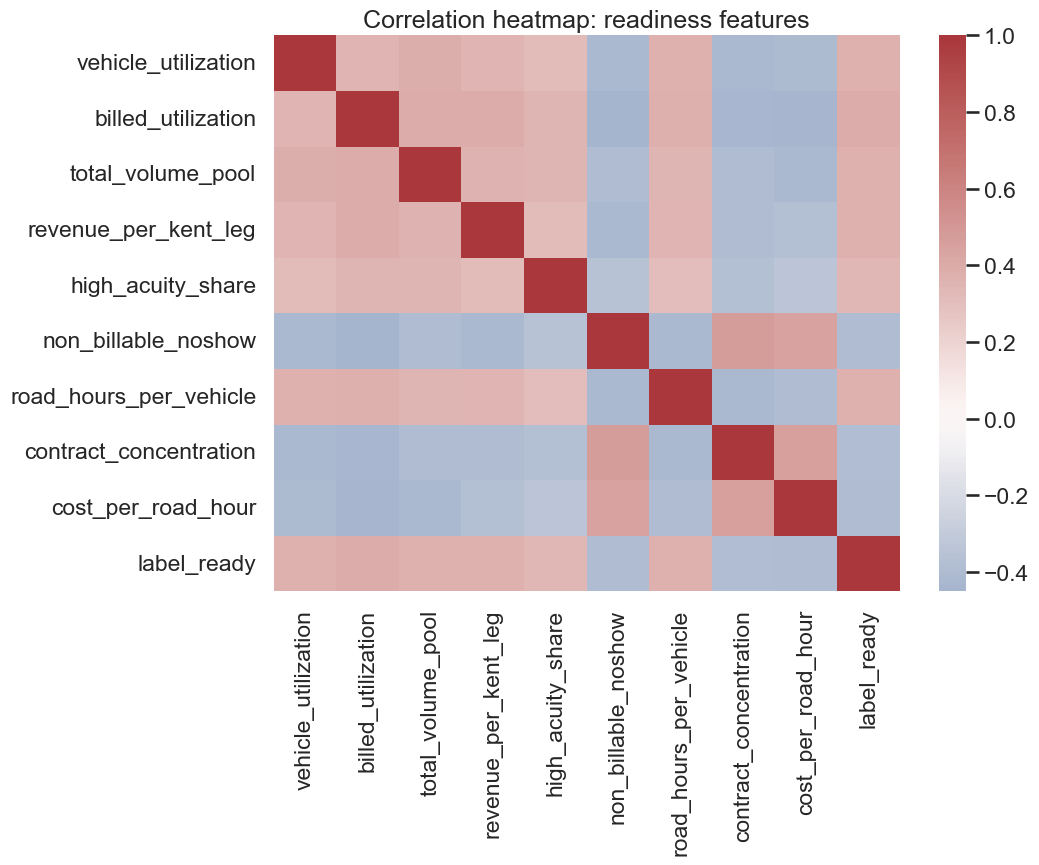

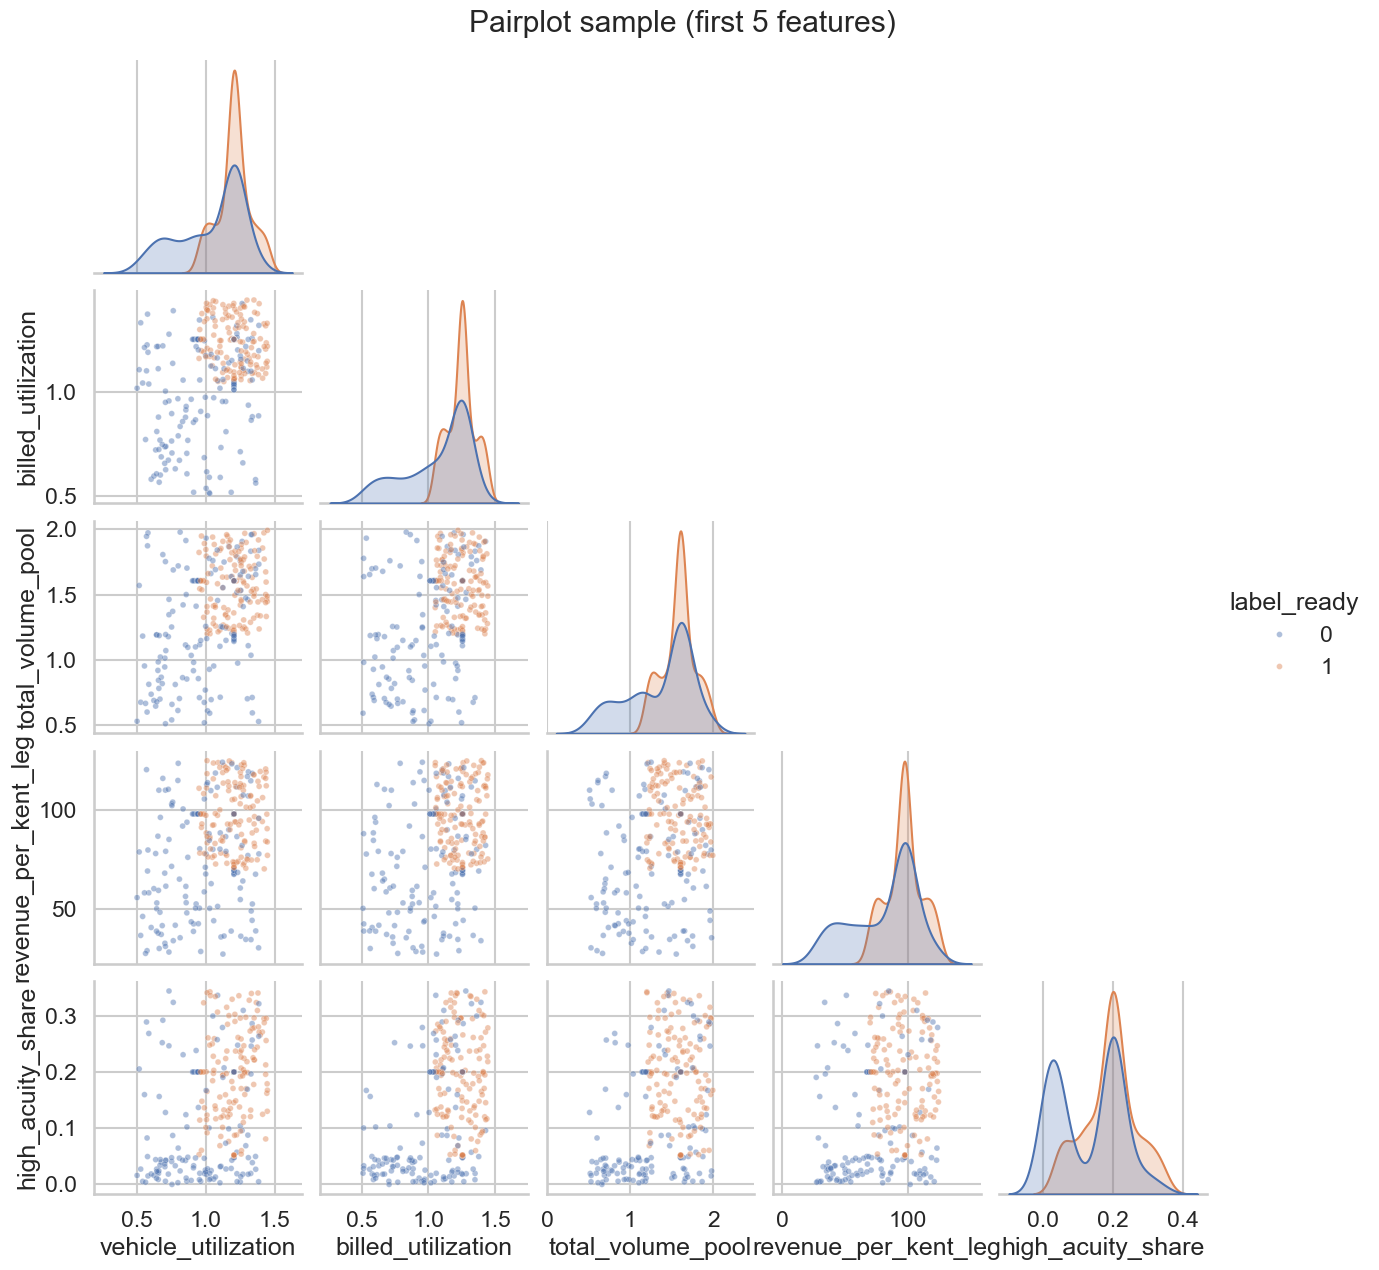

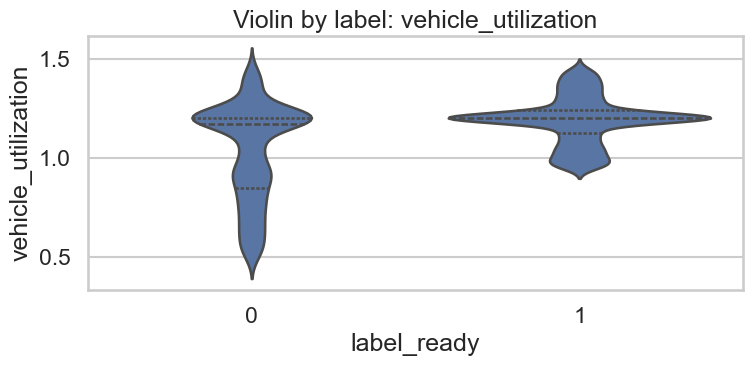

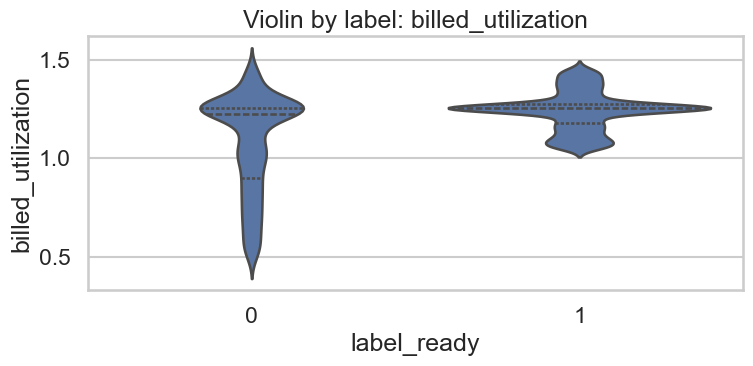

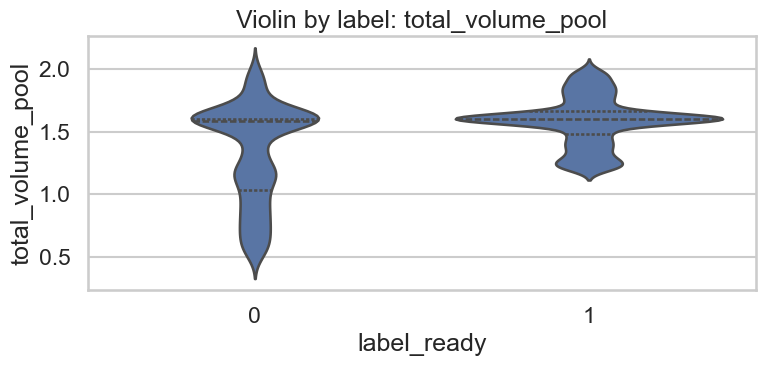

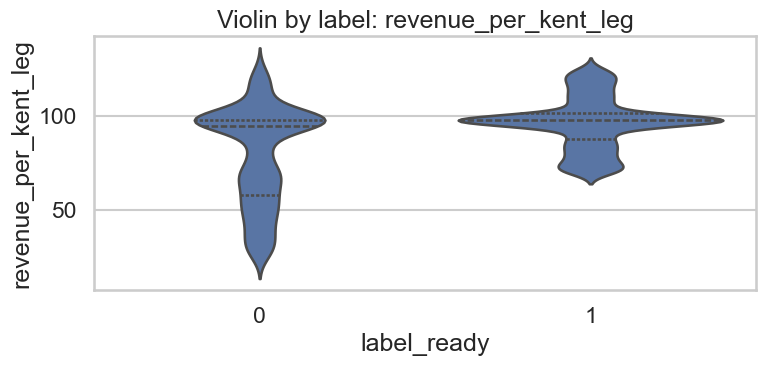

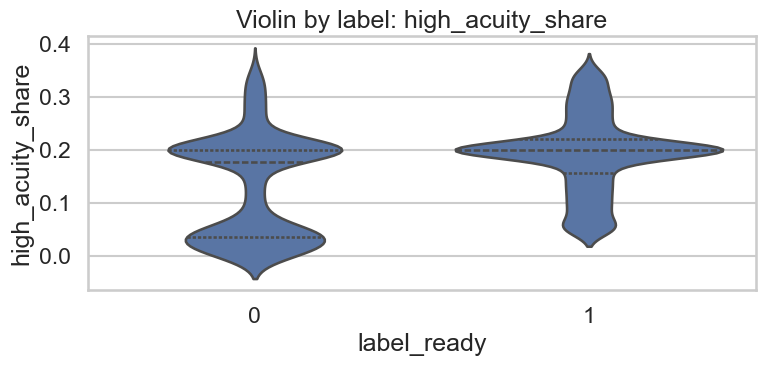

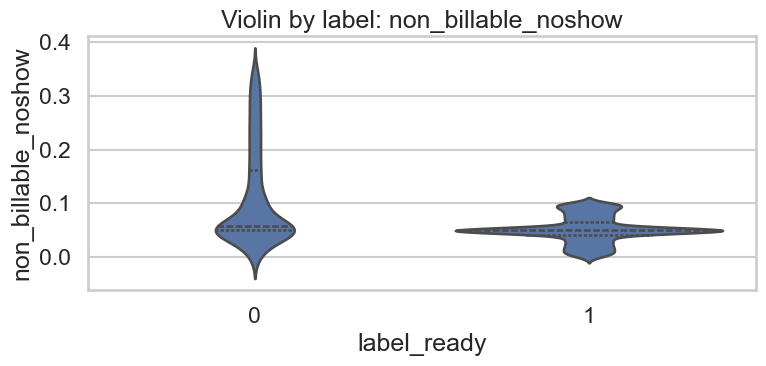

In [11]:

plt.figure(figsize=(11,9))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Correlation heatmap: readiness features")
plt.tight_layout()
plt.savefig(PLOTS / "correlation_heatmap.png", dpi=150)
plt.show()

sample = num.sample(n=min(400, len(num)), random_state=42)
g = sns.pairplot(sample, vars=BACKEND_FEATURES[:5], hue="label_ready", corner=True, plot_kws={"alpha":0.45, "s":18})
g.fig.suptitle("Pairplot sample (first 5 features)", y=1.02)
g.savefig(PLOTS / "pairplot_sample.png", dpi=150)
plt.show()

for f in BACKEND_FEATURES[:6]:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.violinplot(train, x="label_ready", y=f, ax=ax, inner="quartile")
    ax.set_title(f"Violin by label: {f}")
    fig.tight_layout()
    fig.savefig(PLOTS / f"violin_{f}.png", dpi=150)
    plt.show()


In [12]:

notes = []
for _, r in high.head(10).iterrows():
    notes.append({
        "kind": "high",
        "pair": f"{r.feature_a} vs {r.feature_b}",
        "corr": float(r["corr"]),
        "explanation": "Strong linear co-movement: may indicate redundant information across gates; interventions on one lever may move the other.",
    })
for _, r in low.head(10).iterrows():
    notes.append({
        "kind": "low",
        "pair": f"{r.feature_a} vs {r.feature_b}",
        "corr": float(r["corr"]),
        "explanation": "Weak linear relationship: may represent distinct operational pressures; useful as separate diagnostic angles.",
    })
pd.DataFrame(notes).to_csv(RESULTS / "correlation_inference_notes.csv", index=False)
display(pd.DataFrame(notes))


""



### Workbook-grounded reconstruction (week grain)
Uses `code/inference_engine/src/features.py` helpers aligned with **`code/config/pjtl_kpis_and_formulas.json`** (Kent legs, revenue per Kent-Leg, concentration, operating margin, and related bases).


,week_normalized,order_mode,sum_order_price,sum_kent_legs,sum_order_mileage,completed_count,billed_no_show_count,non_billable_no_show_count,revenue_per_kent_leg,non_billable_rate_completed_branch,...,total_kent_legs,total_revenue_x,total_mileage,road_hours_per_vehicle_row,revenue_per_kent_leg_vehicle_grain,kent_legs_per_road_hour,total_revenue_y,total_cost,profit_margin,contract_concentration_revenue
0,Week 1,Ambulatory,18523.55,310.782381,3824.32,225,0,0,59.602961,0.0,...,671.134286,53385.11,20791,8.472571,79.544603,0.677031,109173.60,129801.06,-0.363053,0.161210
1,Week 1,Stretcher,7442.15,21.316667,158.22,18,0,0,349.123534,0.0,...,671.134286,53385.11,20791,8.472571,79.544603,0.677031,109173.60,129801.06,-0.363053,0.161210
2,Week 1,Wheelchair,24182.27,346.035238,3059.28,304,0,0,69.883836,0.0,...,671.134286,53385.11,20791,8.472571,79.544603,0.677031,109173.60,129801.06,-0.363053,0.161210
3,Week 2,Ambulatory,30159.05,554.390952,6545.13,390,0,0,54.400329,0.0,...,1172.109524,87194.77,32950,8.683829,74.391316,0.789334,176938.64,154515.28,0.173557,0.174586
4,Week 2,Stretcher,13781.21,41.148571,526.92,24,0,0,334.913450,0.0,...,1172.109524,87194.77,32950,8.683829,74.391316,0.789334,176938.64,154515.28,0.173557,0.174586


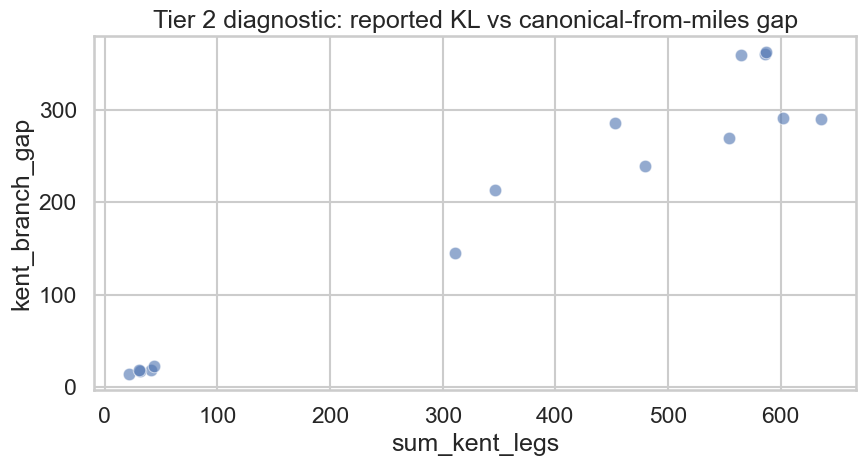

In [13]:
import sys
sys.path.insert(0, str(ENGINE / "src"))
from features import (
    build_mode_summary_week_features,
    build_vehicle_week_features,
    build_weekly_margin_quarter_slice,
    payer_concentration_by_week,
    merge_weekly_analytic_frame,
    operating_margin,
)

ms = tables["mode_summary_base"]
vd = tables["vehicle_day_base"]
wm = tables["weekly_margin_base"]
ps = tables["payer_summary_base"]

mode_week = build_mode_summary_week_features(ms)
veh_week = build_vehicle_week_features(vd)
margin_w = build_weekly_margin_quarter_slice(wm)
conc = payer_concentration_by_week(ps)
analytic = merge_weekly_analytic_frame(mode_week, veh_week, margin_w, conc)
if {"total_revenue","total_cost"}.issubset(analytic.columns):
    analytic["profit_margin"] = operating_margin(analytic["total_revenue"], analytic["total_cost"])
analytic.to_csv(RESULTS / "analytic_week_mode.csv", index=False)
display(analytic.head())

# Example dual-branch diagnostic: Kent reconstruction delta (KPI config + features.py helpers)
from features import kent_legs_from_miles_canonical, kent_legs_from_miles_alternate
if "sum_order_mileage" in analytic.columns:
    m = pd.to_numeric(analytic["sum_order_mileage"], errors="coerce")
    analytic["kent_alt_div85"] = kent_legs_from_miles_alternate(m, 8.5)
    analytic["kent_canonical_from_miles"] = kent_legs_from_miles_canonical(m)
    analytic["kent_branch_gap"] = analytic.get("sum_kent_legs", np.nan) - analytic["kent_canonical_from_miles"]
    analytic.to_csv(RESULTS / "analytic_week_mode.csv", index=False)

fig, ax = plt.subplots(figsize=(9,5))
sns.scatterplot(analytic.dropna(subset=["kent_branch_gap"]), x="sum_kent_legs", y="kent_branch_gap", ax=ax, alpha=0.6)
ax.set_title("Tier 2 diagnostic: reported KL vs canonical-from-miles gap")
plt.tight_layout()
plt.savefig(PLOTS / "kent_branch_gap_scatter.png", dpi=150)
plt.show()


## Which features are used for the production model — and why?

The **nine inputs** in `readiness_training_base.csv` are fixed for this project because:

1. **PJTL put them in the training table** (`readiness_training_base.csv`) together with `label_ready` — that is the supervised snapshot we are allowed to learn from.
2. **The live Ride YourWay API expects exactly those nine names** in the same order when it calls the XGBoost model (vehicle utilization, billed utilization, volume pool, revenue per Kent leg, high-acuity share, non-billable no-show, road hours per vehicle, contract concentration, cost per road hour).

So we are **not** running automatic feature selection to swap them out. EDA tells us how they behave; ablation (Stage 2) tells us which ones the model leans on **within** that fixed set.

The next subsection adds **extra columns for exploration only** — they are **not** sent to the production API.


### Extra columns for exploration only (not sent to the live API)

The live backend only accepts the **nine PJTL metrics** listed above. Here we multiply a few of those metrics together to **test ideas** (for example: “high utilization and high contract concentration at the same time might be extra risky”).

Those multiplied columns are saved in `stage1_row_level_augments.csv` for optional research. **Stage 3 still trains on the nine original columns only**, so the shipped model stays aligned with the API.

Metric definitions and gate rules remain **`code/config/pjtl_kpis_and_formulas.json`**.


In [14]:
aug = train[BACKEND_FEATURES + ["label_ready"]].copy()
aug["stress_utilization_x_concentration"] = aug["vehicle_utilization"] * aug["contract_concentration"]
aug["stress_acuity_x_cost"] = aug["high_acuity_share"] * aug["cost_per_road_hour"]

_cfg_ref = f"code/config/pjtl_kpis_and_formulas.json (schema {_kpi_cfg.get('schema_version', '')})"
fe_log = [
    {
        "feature_name": "stress_utilization_x_concentration",
        "formula_authority": _cfg_ref + " — exploratory product: vehicle_utilization × contract_concentration",
        "inputs": ["vehicle_utilization", "contract_concentration"],
        "null_handling": "product after coercing numeric; NaN preserved",
        "in_backend_contract": False,
        "purpose": "Exploratory stress proxy for operational concentration under load",
    },
    {
        "feature_name": "stress_acuity_x_cost",
        "formula_authority": _cfg_ref + " — exploratory product: high_acuity_share × cost_per_road_hour",
        "inputs": ["high_acuity_share", "cost_per_road_hour"],
        "null_handling": "product after coercing numeric",
        "in_backend_contract": False,
        "purpose": "Exploratory cost intensity under acuity pressure",
    },
]
(RESULTS / "feature_engineering_log.json").write_text(json.dumps(fe_log, indent=2), encoding="utf-8")
aug.to_csv(RESULTS / "stage1_row_level_augments.csv", index=False)

stage1_model = train.dropna(subset=BACKEND_FEATURES + ["label_ready"]).copy()
stage1_model.to_csv(RESULTS / "stage1_model_frame.csv", index=False)

summary = {
    "stage": "stage1",
    "rows_model_frame": int(len(stage1_model)),
    "backend_features": BACKEND_FEATURES,
    "kpi_config": "code/config/pjtl_kpis_and_formulas.json",
    "kpi_schema_version": _kpi_cfg.get("schema_version"),
    "manifest_generated_at_utc": manifest.get("generated_at_utc"),
}
(RESULTS / "stage1_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(Markdown("Wrote `stage1_model_frame.csv` (export path) and `stage1_row_level_augments.csv` (research-only)."))


Wrote `stage1_model_frame.csv` (export path) and `stage1_row_level_augments.csv` (research-only).

In [15]:
# Answers to Stage 1 research questions (filled from saved results; re-run after pipeline cells)
import json
import pandas as pd
from IPython.display import display, Markdown

inv = pd.read_csv(RESULTS / "table_inventory.csv")
cb = pd.read_csv(RESULTS / "class_balance_profile.csv")
hc = pd.read_csv(RESULTS / "high_corr_pairs.csv").head(5)
lc = pd.read_csv(RESULTS / "low_corr_pairs.csv").head(5)
mf = pd.read_csv(RESULTS / "stage1_model_frame.csv")
an = pd.read_csv(RESULTS / "analytic_week_mode.csv")
kent_note = ""
if "kent_branch_gap" in an.columns and an["kent_branch_gap"].notna().any():
    kent_note = f"Week×mode table has Kent reconstruction gap (mean abs gap = {float(an['kent_branch_gap'].abs().mean()):.3f})."
else:
    kent_note = "Kent branch gap column not available or all NaN; see analytic_week_mode.csv."

lines = []
lines.append("## Answers to the research questions (Stage 1)\n")
lines.append(f"**Q1 — What does each PJTL-provided table contain?** We loaded {len(inv)} CSVs; row/column counts are in `table_inventory.csv` and per-table `dtypes_*.csv` / `head_tail_log.txt`.\n\n")
lines.append(f"**Q2 — How complete / balanced is readiness training?** After dropping incomplete rows, **{len(mf)}** rows feed the model frame. Class counts:\n```\n{cb.to_string(index=False)}\n```\n\n")
lines.append("**Q3 — Which feature pairs move together vs independently?** Highest |correlation| pairs (multicollinearity risk):\n```\n" + hc.to_string(index=False) + "\n```\nLowest |correlation| pairs (more independent):\n```\n" + lc.to_string(index=False) + "\n```\n\n")
lines.append("**Q4 — Where do alternate formula branches show up?** We rebuilt week×mode KPIs with `features.py` and the shared KPI config. " + kent_note + " See `analytic_week_mode.csv` and `kent_branch_gap_scatter.png`.\n\n")
lines.append("**Q5 — What exploration-only composites did we add?** `stress_utilization_x_concentration` and `stress_acuity_x_cost` in `stage1_row_level_augments.csv`, documented in `feature_engineering_log.json`. They are **not** production API inputs.\n")
display(Markdown("".join(lines)))


## Answers to the research questions (Stage 1)
**Q1 — What does each PJTL-provided table contain?** We loaded 17 CSVs; row/column counts are in `table_inventory.csv` and per-table `dtypes_*.csv` / `head_tail_log.txt`.

**Q2 — How complete / balanced is readiness training?** After dropping incomplete rows, **4000** rows feed the model frame. Class counts:
```
 label  count    rate
     1   2027 0.50675
     0   1973 0.49325
```

**Q3 — Which feature pairs move together vs independently?** Highest |correlation| pairs (multicollinearity risk):
```
Empty DataFrame
Columns: [feature_a, feature_b, corr, abs_corr]
Index: []
```
Lowest |correlation| pairs (more independent):
```
Empty DataFrame
Columns: [feature_a, feature_b, corr, abs_corr]
Index: []
```

**Q4 — Where do alternate formula branches show up?** We rebuilt week×mode KPIs with `features.py` and the shared KPI config. Week×mode table has Kent reconstruction gap (mean abs gap = 193.781). See `analytic_week_mode.csv` and `kent_branch_gap_scatter.png`.

**Q5 — What exploration-only composites did we add?** `stress_utilization_x_concentration` and `stress_acuity_x_cost` in `stage1_row_level_augments.csv`, documented in `feature_engineering_log.json`. They are **not** production API inputs.
